# Plant Disease Classification - Evaluation
This notebook tests our trained CNN on completely unseen leaf images.

In [1]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import sys
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

# Add src to the path so we can import our model and dataset classes
sys.path.append('../src')
from model import PlantDiseaseCNN
from dataset import get_data_loaders

## 1. Load the Model
We will load the weights from our best performing model (Experiment 2).

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# We need to know the number of classes. We can get this from our get_data_loaders function.
_, _, _, classes = get_data_loaders('../data', batch_size=1)
num_classes = len(classes)

model = PlantDiseaseCNN(num_classes=num_classes)

# Load the trained weights from Experiment 2 (98.3% accuracy!)
model_path = '../models/plant_disease_cnn_exp4_100epochs_model.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval() # Set to evaluation mode (turns off dropout)

print("Model loaded successfully!")

Using device: cuda
Model loaded successfully!


## 2. Preprocess the Image
We must apply the exact same mathematical transformations to the test image as we did to the training images.

In [3]:
# The exact same transform from dataset.py (Resize, ToTensor, Normalize)
# We do NOT include RandomFlip or RandomRotation because we are just evaluating.
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_image(image_path, model, transform, classes, top_k=3):
    # 1. Load and display the image
    img = Image.open(image_path).convert('RGB')
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    # 2. Preprocess the image
    img_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension
    
    # 3. Model Inference
    with torch.no_grad():
        outputs = model(img_tensor)
        
    # 4. Convert raw scores to percentages (Softmax)
    probabilities = F.softmax(outputs, dim=1)[0] * 100
    
    # 5. Get top predictions
    top_prob, top_catid = torch.topk(probabilities, top_k)
    
    print("\n--- Predictions ---")
    for i in range(top_k):
        class_name = classes[top_catid[i]]
        score = top_prob[i].item()
        print(f"{i+1}. {class_name} ({score:.2f}%)")


## 3. Test on a New Image!
Provide a path to any image in the `../data/test/` directory to see the model's guess.


--- Testing Image 1 ---
** Ground Truth (from filename): PotatoHealthy2.JPG **


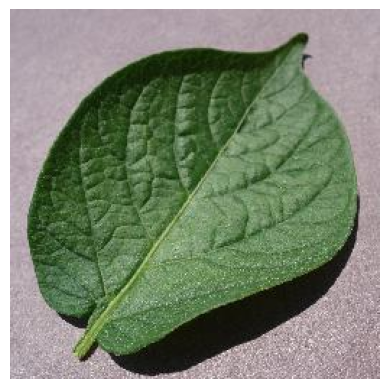


--- Predictions ---
1. Potato___healthy (100.00%)
2. Potato___Late_blight (0.00%)
3. Soybean___healthy (0.00%)

--- Testing Image 2 ---
** Ground Truth (from filename): TomatoHealthy3.JPG **


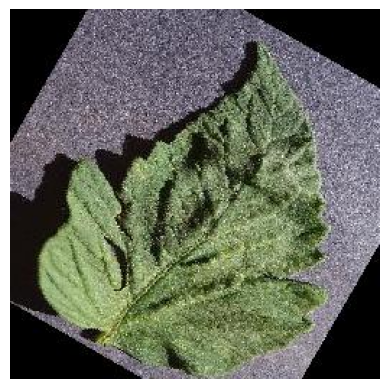


--- Predictions ---
1. Tomato___healthy (100.00%)
2. Tomato___Target_Spot (0.00%)
3. Tomato___Late_blight (0.00%)

--- Testing Image 3 ---
** Ground Truth (from filename): AppleCedarRust3.JPG **


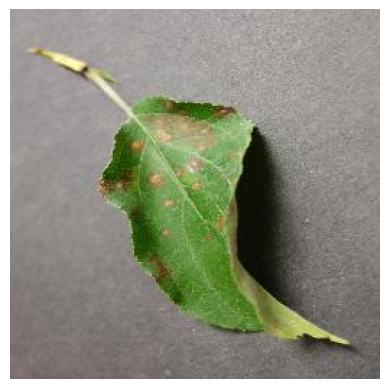


--- Predictions ---
1. Apple___Cedar_apple_rust (100.00%)
2. Tomato___Bacterial_spot (0.00%)
3. Peach___Bacterial_spot (0.00%)

--- Testing Image 4 ---
** Ground Truth (from filename): TomatoEarlyBlight5.JPG **


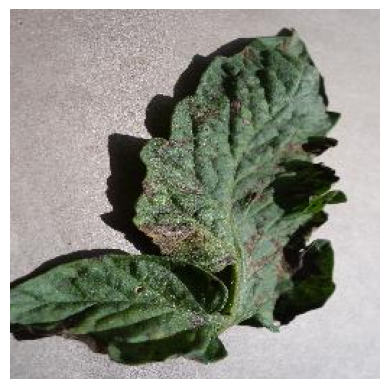


--- Predictions ---
1. Tomato___Early_blight (99.99%)
2. Tomato___Late_blight (0.01%)
3. Tomato___Target_Spot (0.00%)

--- Testing Image 5 ---
** Ground Truth (from filename): AppleScab2.JPG **


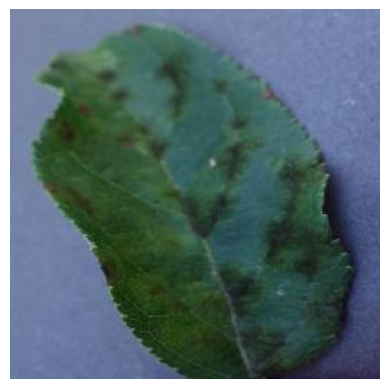


--- Predictions ---
1. Apple___Apple_scab (95.46%)
2. Tomato___Leaf_Mold (4.53%)
3. Apple___healthy (0.01%)


In [4]:
# Let's pick 5 random images from the Kaggle test set
import glob
import random
import os

# The kaggle test set places images inside a 'test' subfolder
test_images = glob.glob('../data/test/test/*.[jJ][pP][gG]') + glob.glob('../data/test/test/*.[jJ][pP][eE][gG]')

if test_images:
    # Randomly select 5 images
    num_images_to_test = min(5, len(test_images))
    random_test_images = random.sample(test_images, num_images_to_test)
    
    # Loop through each of the 5 images and run the prediction
    for i, img_path in enumerate(random_test_images):
        print(f"\n--- Testing Image {i+1} ---")
        
        # Extract the true disease from the filename
        filename = os.path.basename(img_path)
        print(f"** Ground Truth (from filename): {filename} **")
        
        predict_image(img_path, model, eval_transform, classes, top_k=3)
else:
    print("No test images found in ../data/test/test/")
